In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.special import kn
from scipy.integrate import cumulative_trapezoid
import pandas as pd

In [8]:
df = pd.read_csv("geff.txt", sep = '\s+')
df

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3402487/3808965406.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("geff.txt", sep = '\s+')


,T[GeV],heff,geff
0,12589.200000,106.83000,106.83000
1,11885.000000,106.83000,106.83000
2,11220.200000,106.83000,106.83000
3,10592.600000,106.83000,106.83000
4,10000.000000,106.83000,106.83000
...,...,...,...
271,0.000028,3.93873,3.38389
272,0.000025,3.93872,3.38388
273,0.000022,3.93872,3.38387
274,0.000020,3.93872,3.38387


In [9]:
geff = df['geff']
Teff = df['T[GeV]']

In [10]:
from scipy.interpolate import CubicSpline

Teff_sorted = Teff.iloc[::-1].values
geff_sorted = geff.iloc[::-1].values

geff_spline = CubicSpline(Teff_sorted, geff_sorted, bc_type='natural')

def geff(T):
    return geff_spline(T)

In [11]:
m_psi = 100
x_full = np.logspace(-4, 3, 5000)
T_array = m_psi / x_full


g_s_array = geff(T_array)
dg_s_dx = np.gradient(g_s_array, x_full)
H_correction = 1.0 - (1.0 / 3.0) * (x_full / g_s_array) * dg_s_dx

integrand_exact = (x_full**4) * (kn(2, x_full)**2) * H_correction * (106.75 / g_s_array)**1.5

integral_full = cumulative_trapezoid(integrand_exact, x_full, initial=0)

sigma_v_ref = 0.12 / integral_full[-1]



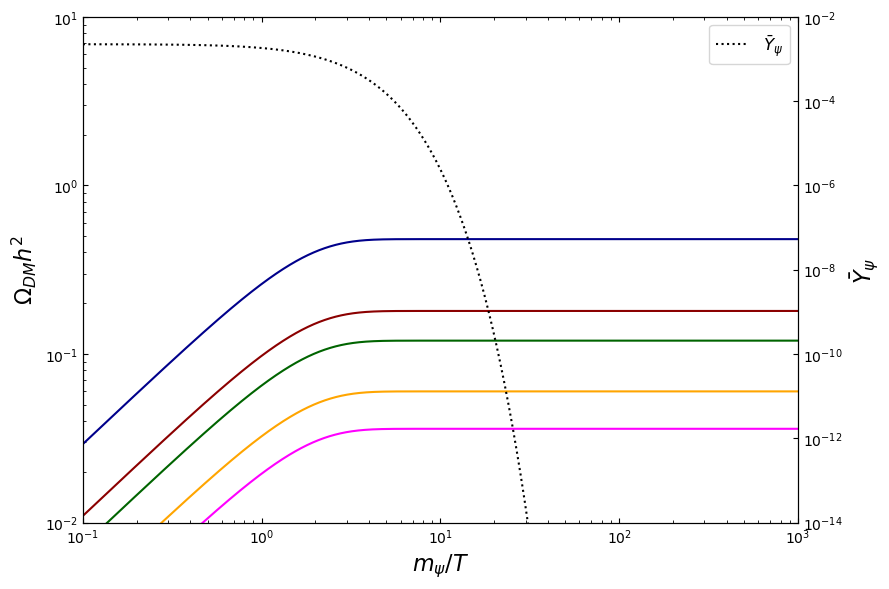

In [12]:
mask = x_full >= 0.1
x_plot = x_full[mask]
integral_plot = integral_full[mask]

fig, ax1 = plt.subplots(figsize=(9, 6))


multiplicadores = [4, 1.5, 1.0, 0.5, 0.3]
colores = ['darkblue', 'darkred', 'darkgreen', 'orange', 'magenta']

for mult, color in zip(multiplicadores, colores):
    Omega_h2 = mult * sigma_v_ref * integral_plot
    ax1.plot(x_plot, Omega_h2, color=color)


ax2 = ax1.twinx()
Y_eq = 1.12e-3 * (x_plot**2) * kn(2, x_plot)
ax2.plot(x_plot, Y_eq, 'k:', label='$\\bar{Y}_\\psi$')


ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')

ax1.set_xlim(1e-1, 1e3)
ax1.set_ylim(1e-2, 1e1)
ax2.set_ylim(1e-14, 1e-2)

ax1.set_xlabel('$m_\\psi / T$', fontsize=16)
ax1.set_ylabel('$\\Omega_{DM} h^2$', fontsize=16)
ax2.set_ylabel('$\\bar{Y}_\\psi$', fontsize=16)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=12)

ax1.tick_params(axis='both', which='both', direction='in', top=True, right=False)
ax2.tick_params(axis='y', which='both', direction='in')

plt.tight_layout()
plt.show()